# ASSIGNMENT 10

## Comparing GAN and VAE Using Your Own Experimental Results

**Name:** **Prakruthi BR**

**Subject:** **Generative AI**

**Reg NO:** **2411021240038**

### Objective

The objective of this assignment is to compare a GAN and a VAE using the practical results obtained from previous experiments rather than only theoretical knowledge.

The comparison is based on:

- Image sharpness
- Diversity
- Realism
- Training stability
- Ease of controlling the output
- Risk of mode collapse
- Typical applications

The experimental results used in this assignment are:

- Assignment 4: Training a DCGAN on the Fashion-MNIST Dataset
- Assignment 8: Building a Variational Autoencoder and Visualising Its Latent Space

## 1. Experimental Results Used

### GAN – Assignment 4

In Assignment 4, a Deep Convolutional Generative Adversarial Network (DCGAN) was implemented using the Fashion-MNIST dataset.

The DCGAN was trained for 25 epochs with a latent dimension of 100.

Generated image grids were saved at Epochs 5, 10, 15, 20 and 25.

The generated images from the final stages of training are used in this assignment to evaluate image sharpness, diversity and realism.

### VAE – Assignment 8

In Assignment 8, a Variational Autoencoder (VAE) was implemented using the MNIST handwritten-digit dataset.

The VAE used a 2-dimensional latent space and was trained for 20 epochs.

The VAE generated 225 images by selecting latent coordinates between approximately -3 and +3.

The generated images and latent-space results are used to evaluate diversity, controllability and generation behavior.

In [2]:
import json
import base64
import io
import os

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

In [3]:
import os

print("Files available in Colab:")

for file in os.listdir("/content"):
    print(file)

Files available in Colab:
.config
ASSIGNMENT_8_Building_a_Variational_Autoencoder_and_Visualising_Its_Latent_Space_(GEN_AI).ipynb
Assignment_4_Training_a_DCGAN_on_Fashion_MNIST_Dataset_(GEN_AI).ipynb
sample_data


In [4]:
import glob

assignment4_files = glob.glob(
    "/content/*Assignment_4*.ipynb"
)

assignment8_files = glob.glob(
    "/content/*ASSIGNMENT_8*.ipynb"
)

print("Assignment 4 file:")
print(assignment4_files)

print("\nAssignment 8 file:")
print(assignment8_files)

Assignment 4 file:
['/content/Assignment_4_Training_a_DCGAN_on_Fashion_MNIST_Dataset_(GEN_AI).ipynb']

Assignment 8 file:
['/content/ASSIGNMENT_8_Building_a_Variational_Autoencoder_and_Visualising_Its_Latent_Space_(GEN_AI).ipynb']


In [5]:
# Load Assignment 4 notebook

assignment4_path = assignment4_files[0]

with open(
    assignment4_path,
    "r",
    encoding="utf-8"
) as f:
    assignment4_notebook = json.load(f)

print("Assignment 4 notebook loaded successfully.")
print(
    "Number of cells:",
    len(assignment4_notebook["cells"])
)

Assignment 4 notebook loaded successfully.
Number of cells: 56


In [6]:
# Find image outputs from Assignment 4

gan_output_images = []

for cell_number, cell in enumerate(
    assignment4_notebook["cells"]
):

    for output in cell.get("outputs", []):

        data = output.get("data", {})

        if "image/png" in data:

            image_data = base64.b64decode(
                data["image/png"]
            )

            image = Image.open(
                io.BytesIO(image_data)
            )

            gan_output_images.append(
                (cell_number, image)
            )

print(
    "GAN image outputs found:",
    len(gan_output_images)
)

for cell_number, image in gan_output_images:
    print(
        "Cell:",
        cell_number,
        "Image size:",
        image.size
    )

GAN image outputs found: 5
Cell: 18 Image size: (636, 658)
Cell: 24 Image size: (481, 504)
Cell: 44 Image size: (1783, 397)
Cell: 48 Image size: (846, 547)
Cell: 50 Image size: (378, 1990)


GAN comparison image extracted successfully.
Image size: (1783, 397)


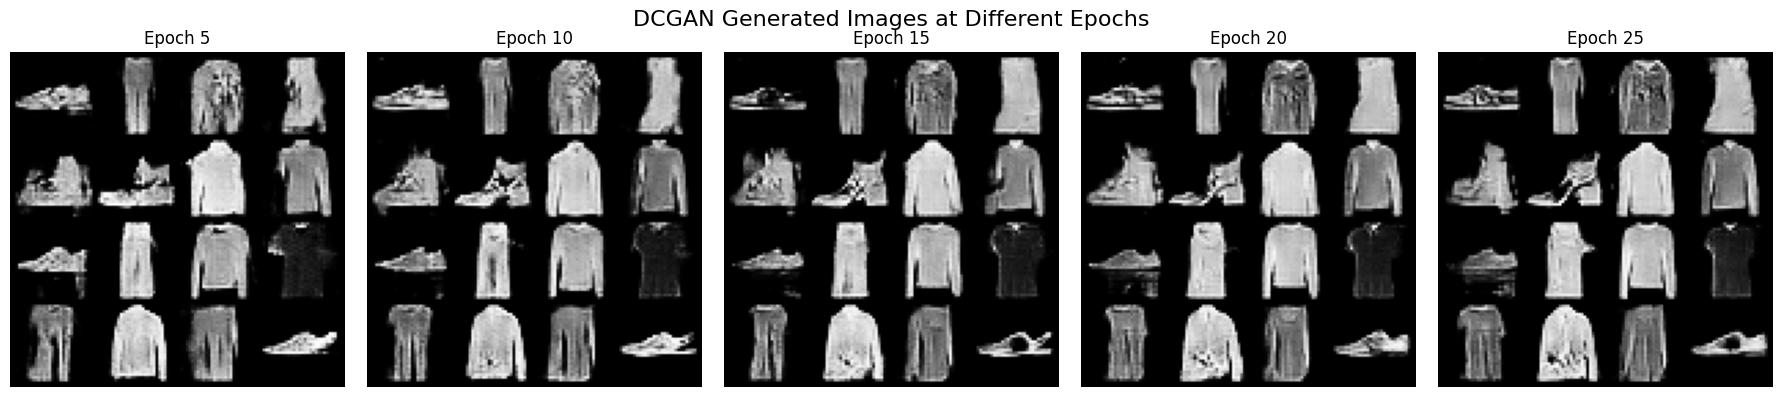

In [7]:
# Extract the actual Assignment 4 Step 22 output

gan_cell = assignment4_notebook["cells"][44]

gan_image_output = None

for output in gan_cell.get("outputs", []):

    data = output.get("data", {})

    if "image/png" in data:

        gan_image_output = Image.open(
            io.BytesIO(
                base64.b64decode(
                    data["image/png"]
                )
            )
        )

        break

if gan_image_output is None:
    raise ValueError(
        "GAN Step 22 image output was not found."
    )

print(
    "GAN comparison image extracted successfully."
)

print(
    "Image size:",
    gan_image_output.size
)

display(gan_image_output)

## 2. GAN Experimental Result

The DCGAN results from Assignment 4 were generated at Epochs 5, 10, 15, 20 and 25.

The generated images show how the Generator output changes as training progresses.

The later epochs produce more recognizable Fashion-MNIST-like structures compared with the early stages of training.

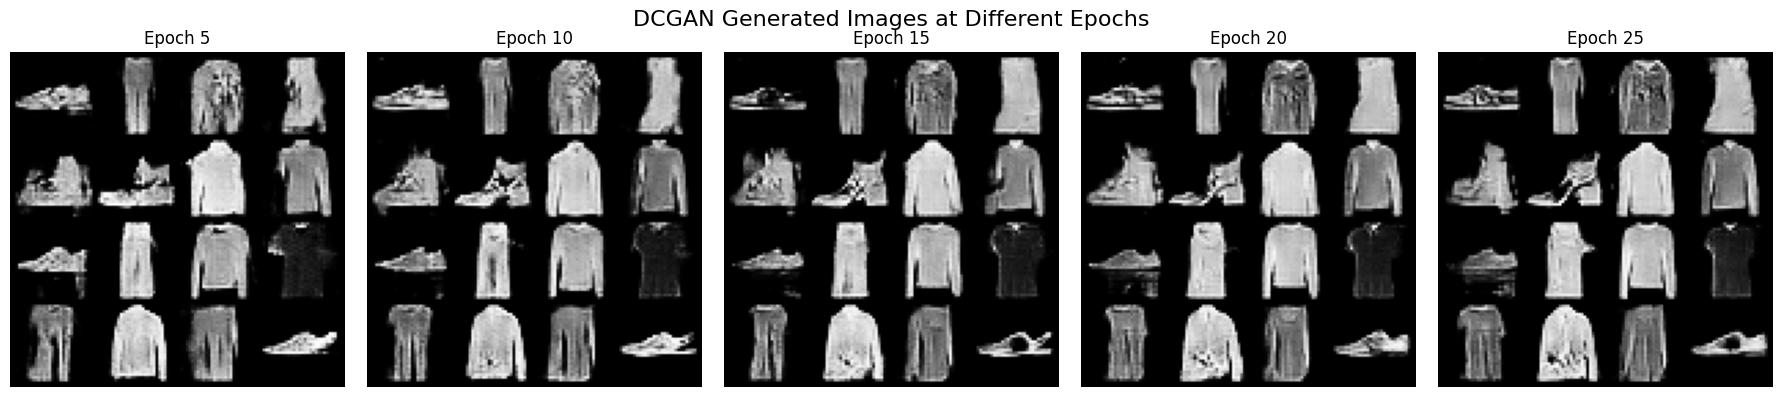

In [8]:
display(gan_image_output)

In [9]:
# Load Assignment 8 notebook

assignment8_path = assignment8_files[0]

with open(
    assignment8_path,
    "r",
    encoding="utf-8"
) as f:
    assignment8_notebook = json.load(f)

print("Assignment 8 notebook loaded successfully.")

print(
    "Number of cells:",
    len(assignment8_notebook["cells"])
)

Assignment 8 notebook loaded successfully.
Number of cells: 77


VAE generated-image grid extracted successfully.
Image size: (1187, 1180)


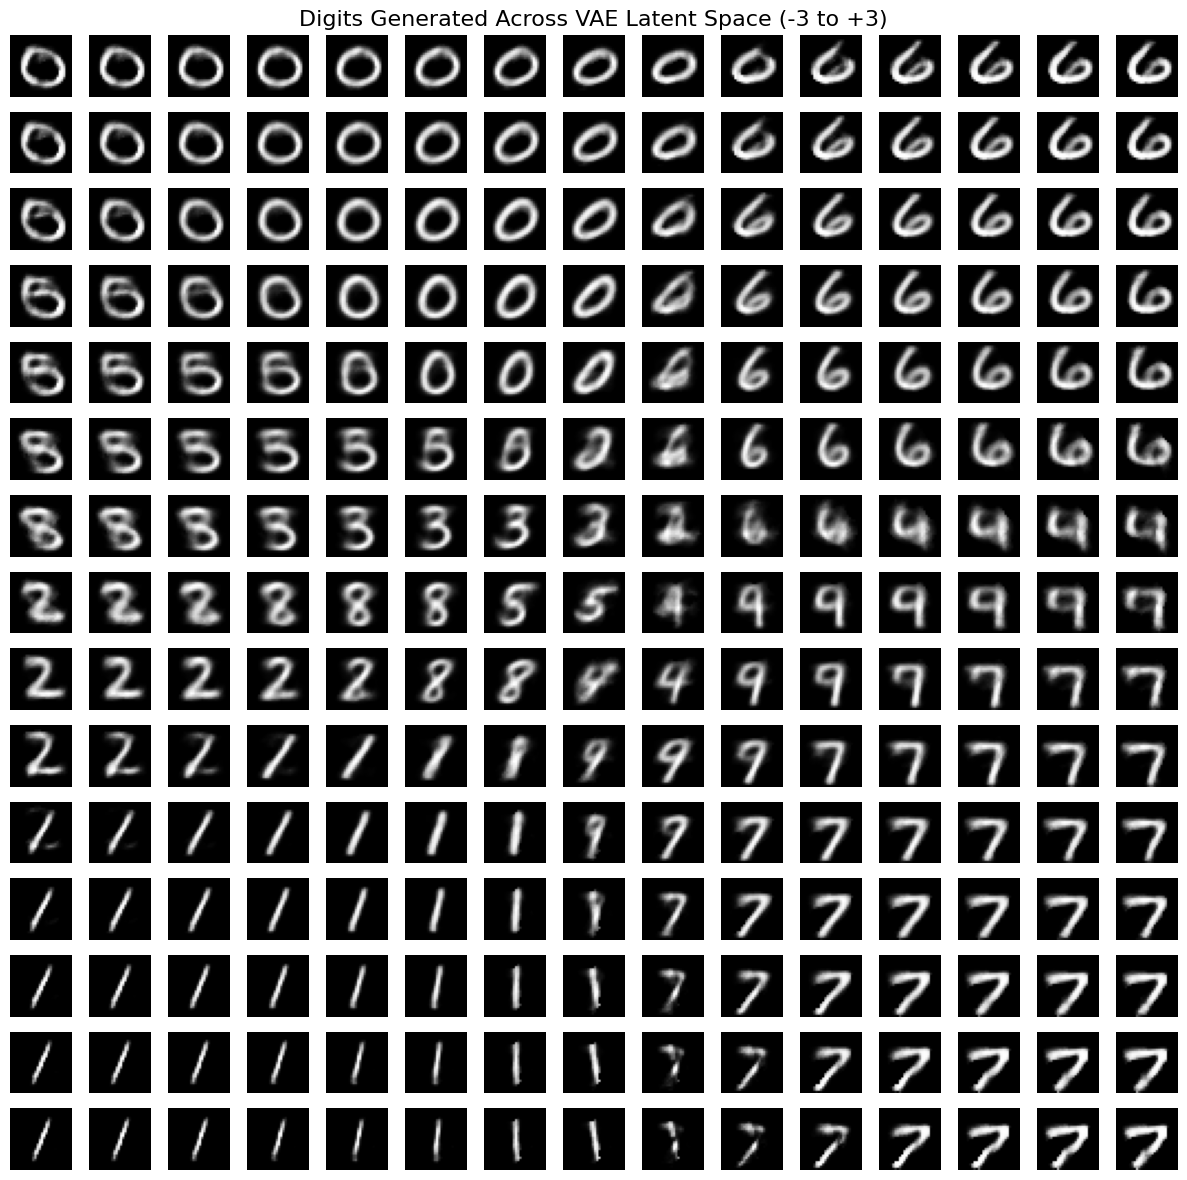

In [10]:
# Extract the actual VAE generated-image grid

vae_cell = assignment8_notebook["cells"][67]

vae_grid_output = None

for output in vae_cell.get("outputs", []):

    data = output.get("data", {})

    if "image/png" in data:

        vae_grid_output = Image.open(
            io.BytesIO(
                base64.b64decode(
                    data["image/png"]
                )
            )
        )

        break

if vae_grid_output is None:
    raise ValueError(
        "VAE generated-image grid was not found."
    )

print(
    "VAE generated-image grid extracted successfully."
)

print(
    "Image size:",
    vae_grid_output.size
)

display(vae_grid_output)

## 3. VAE Experimental Result

The VAE generated images by selecting points across a 2-dimensional latent space.

The latent coordinates ranged approximately from -3 to +3.

A 15 × 15 grid was generated, resulting in 225 generated images.

The generated digits generally change gradually as the latent coordinates change, demonstrating the continuous nature of the learned latent space.

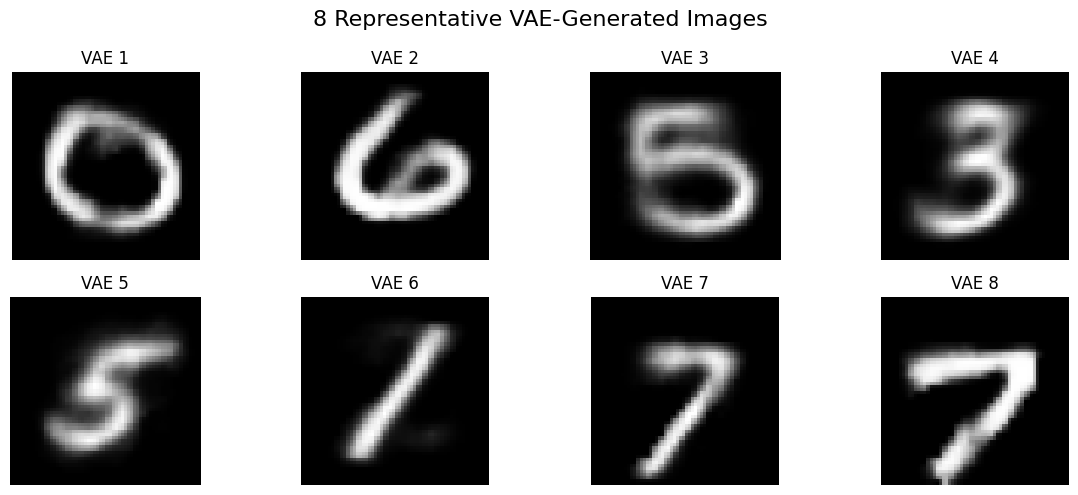

In [19]:
# Correctly extract 8 representative images
# from the original 15 x 15 VAE output.

vae_array = np.array(
    vae_grid_output.convert("L")
)

# Actual image boundaries in the saved Assignment 8 output.
row_ranges = [
    (35, 97),
    (112, 173),
    (188, 250),
    (265, 327),
    (342, 403),
    (418, 480),
    (495, 557),
    (572, 633),
    (648, 710),
    (725, 787),
    (802, 863),
    (878, 940),
    (955, 1017),
    (1032, 1093),
    (1108, 1170)
]

col_ranges = [
    (10, 72),
    (89, 151),
    (168, 230),
    (247, 309),
    (326, 388),
    (405, 467),
    (484, 546),
    (563, 625),
    (642, 704),
    (721, 783),
    (800, 862),
    (879, 941),
    (958, 1020),
    (1037, 1099),
    (1116, 1178)
]

# Select 8 representative images
# with good variation across the latent space.

positions = [
    (0, 0),
    (0, 14),
    (4, 2),
    (6, 6),
    (7, 7),
    (9, 3),
    (12, 9),
    (14, 14)
]

selected_vae_images = []

for row, col in positions:

    y1, y2 = row_ranges[row]
    x1, x2 = col_ranges[col]

    crop = vae_array[
        y1:y2,
        x1:x2
    ]

    selected_vae_images.append(crop)

plt.figure(figsize=(12, 5))

for i, image in enumerate(selected_vae_images):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(f"VAE {i + 1}")
    plt.axis("off")

plt.suptitle(
    "8 Representative VAE-Generated Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [20]:
# Convert GAN comparison output to grayscale

gan_array = np.array(
    gan_image_output.convert("L")
)

gan_height, gan_width = gan_array.shape

print(
    "GAN comparison image size:",
    gan_array.shape
)

GAN comparison image size: (397, 1783)


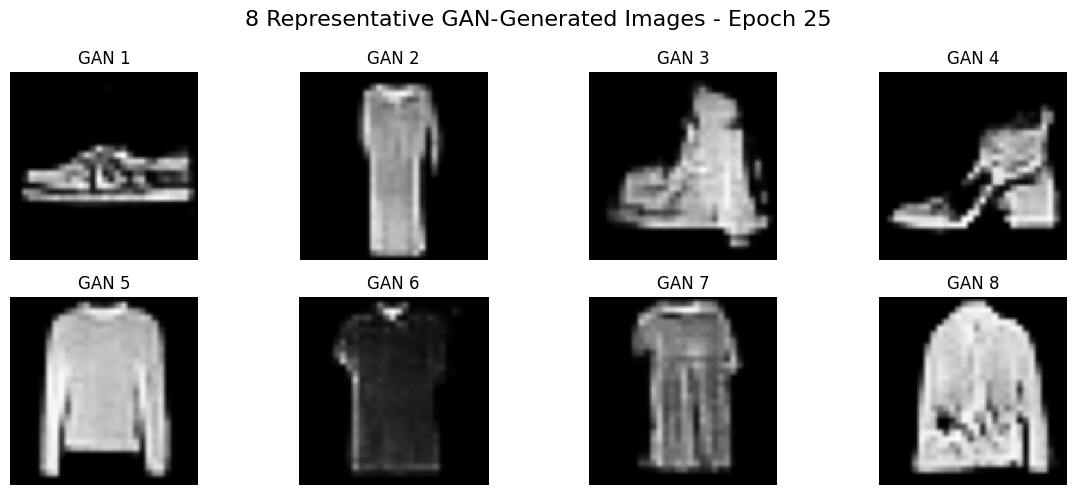

In [21]:
# Correctly extract the Epoch 25 GAN image grid
# from the Assignment 4 comparison output.

gan_array = np.array(
    gan_image_output.convert("L")
)

# Remove the title area and keep only the Epoch 25 panel.
# The original Assignment 4 output is 1783 x 397 pixels.
epoch25_panel = gan_array[
    52:387,
    1438:1773
]

# Select 8 representative images from the 4 x 4 grid.
gan_positions = [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1),
    (2, 2),
    (2, 3),
    (3, 0),
    (3, 1)
]

selected_gan_images = []

for row, col in gan_positions:

    y1 = round(row * epoch25_panel.shape[0] / 4)
    y2 = round((row + 1) * epoch25_panel.shape[0] / 4)

    x1 = round(col * epoch25_panel.shape[1] / 4)
    x2 = round((col + 1) * epoch25_panel.shape[1] / 4)

    crop = epoch25_panel[y1:y2, x1:x2]

    selected_gan_images.append(crop)

plt.figure(figsize=(12, 5))

for i, image in enumerate(selected_gan_images):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(f"GAN {i + 1}")
    plt.axis("off")

plt.suptitle(
    "8 Representative GAN-Generated Images - Epoch 25",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 4. Eight Representative GAN-Generated Images

Eight representative images were selected from the Epoch 25 output of the DCGAN.

The DCGAN was trained for 25 epochs on the Fashion-MNIST dataset.

The selected images demonstrate the final-stage output of the trained Generator.

## 5. Eight Representative VAE-Generated Images

Eight representative images were selected from the 15 × 15 VAE-generated grid.

The images were generated by selecting different points in the learned 2-dimensional latent space.

The VAE generated 225 images across latent coordinates ranging approximately from -3 to +3.

## 6. Experimental Limitation

The GAN and VAE in the previous assignments were trained on different datasets.

The DCGAN was trained on the Fashion-MNIST dataset, which contains clothing images, while the VAE was trained on the MNIST dataset, which contains handwritten digits.

Therefore, the generated images should not be treated as a direct image-quality comparison between the two models.

Instead, this assignment compares the observed characteristics and behavior of the GAN and VAE based on their respective experiments.

# 7. GAN vs VAE Comparison

The GAN and VAE were compared using the results observed in Assignments 4 and 8. Since the two models were trained on different datasets, the comparison focuses on their observed characteristics and behavior rather than directly comparing image quality.

| Comparison Factor | GAN (DCGAN) – Assignment 4 | VAE – Assignment 8 |
|---|---|---|
| **Image Sharpness** | Generated relatively sharper and more defined Fashion-MNIST-like structures, especially in the later stages of training. | Generated recognizable handwritten digits, but the outputs were generally smoother and softer. |
| **Diversity** | Generated different Fashion-MNIST-like clothing structures from different random latent vectors. | Generated different digit shapes by selecting different points in the 2-dimensional latent space. |
| **Realism** | Generated recognizable clothing-like structures that became more realistic as training progressed. | Generated recognizable handwritten digits, although some outputs appeared smoother. |
| **Training Stability** | Training was more difficult to interpret because Generator and Discriminator losses fluctuated due to adversarial competition. | Training was more predictable; the total and validation losses decreased during training. |
| **Ease of Controlling Output** | More difficult to interpret because the GAN used a 100-dimensional latent vector. | Easier to visualize and control because the VAE used a 2-dimensional latent space. |
| **Risk of Mode Collapse** | GANs have a higher risk of mode collapse. No obvious severe mode collapse was observed in the selected Assignment 4 samples. | Does not have the classic GAN mode-collapse problem because it does not use adversarial Generator-Discriminator training. |
| **Typical Applications** | Synthetic image generation, data augmentation, realistic image synthesis and creative content generation. | Image reconstruction, representation learning, dimensionality reduction, latent-space exploration and anomaly detection. |
| **Main Strength** | Produces sharper and more realistic-looking generated images. | Provides a structured and interpretable latent space. |
| **Main Limitation** | Training can be unstable or difficult because of adversarial competition. | Generated images can be smoother or blurrier than GAN outputs. |

# 8. Final Verdict

## 1. Which model would you prefer for generating synthetic training data?

I would prefer the **GAN** for generating synthetic training data when the main requirement is to generate sharp and realistic-looking images.

In my Assignment 4 experiment, the DCGAN generated recognizable Fashion-MNIST-like clothing structures during training.

Therefore, I would prefer the GAN for high-quality synthetic image generation.

## 2. Which model would you prefer for anomaly detection?

I would prefer the **VAE** for anomaly detection.

The VAE learns to reconstruct input data and also learns a structured latent representation.

In Assignment 8, the VAE demonstrated image reconstruction and a 2-dimensional latent space.

Anomaly detection can use reconstruction error or unusual latent representations to identify data that differs from the learned distribution.

Therefore, I would prefer the VAE for anomaly detection.

However, anomaly detection was not directly implemented and evaluated in Assignment 8. This preference is based on the reconstruction and latent-space behavior observed in the experiment.

## 3. Why?

The GAN and VAE have different strengths.

The GAN is better suited for generating sharp and realistic synthetic images because its Generator learns through adversarial competition with the Discriminator.

The VAE provides a structured and continuous latent space and performs reconstruction, making it more suitable for representation learning and reconstruction-based anomaly detection.

Therefore:

- **GAN → Preferred for realistic synthetic training data**
- **VAE → Preferred for anomaly detection**


# 9. Conclusion

This assignment compared a DCGAN and a VAE using the practical results obtained from Assignments 4 and 8.

The DCGAN was trained on Fashion-MNIST for 25 epochs and generated recognizable clothing-like structures. The later training stages showed improved generated samples, while the Generator and Discriminator losses fluctuated because of adversarial training.

The VAE was trained on MNIST for 20 epochs and learned a 2-dimensional latent representation. Its total and validation losses decreased during training, and the latent-space generation demonstrated gradual changes in handwritten digits.

Based on the experimental observations, the GAN is preferred for generating sharp and realistic synthetic training data, while the VAE is preferred for reconstruction-based anomaly detection and latent-space analysis.

The experiment demonstrates that GANs and VAEs have different strengths and should be selected according to the requirements of the application.